# Assignment 3               
## Muhammad Ullah 400529222

You are a biomedical engineer working on the validation of a portable membrane oxygenator
designed for short-term respiratory support in emergency and transport settings.
This device transfers oxygen into blood across a semi-permeable membrane. During operation,
not all supplied gas is efficiently transferred. Some fraction of processed gas is lost and is
designated as DEVICELOSS (the percentage (%) of processed gas that is lost during operation
with higher values indicate worse device efficiency). You want to be able to better understand
and predict DEVICELOSS. The dataset DeviceLoss.csv contains experimental data collected from controlled benchtop
testing of the device. DEVICELOSS and the following predictor variables were use:

GASFLOW:
* Gas flow rate (%) relative to rated operating capacity
* Higher gas flow may increase turbulence and diffusion rate

COOLANT_TEMP:
* Coolant temperature (°C) controlling membrane heat exchange
* Temperature influences gas solubility and membrane permeability
* Nonlinear temperature effects are possible

SURFACTANT_CONC:
* Surfactant concentration (%) used to modify membrane surface properties
* Surfactants can reduce bubble formation and improve diffusion efficiency

### Problem 1: [25 points/100 points] Covariance and Correlation

**a) Load the data and split the data into a 70% train and 30 test dataset using a
random_state=2026. Show the descriptive statistics of the training data.**

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('DeviceLoss.csv')

train_df, test_df = train_test_split(df, test_size=0.30, random_state=2026)

train_stats = train_df.describe()

print(train_stats)

       DEVICELOSS    GASFLOW  COOLANT_TEMP  SURFACTANT_CONC
count   22.000000  22.000000     22.000000        22.000000
mean    11.500909  60.545455     26.772727        89.090909
std      5.311295  13.153769      3.951272         7.963662
min      4.470000  45.000000     20.000000        80.000000
25%      8.282500  49.250000     24.250000        80.000000
50%      9.655000  55.000000     25.000000        90.000000
75%     13.952500  70.750000     30.000000        95.000000
max     24.030000  84.000000     34.000000       100.000000


**b) Produce a pairplot showing all pairwise relationships for the training data. Briefly, discuss:**

**• Which predictor appears most strongly linearly associated with DEVICELOSS?**

**• Does COOLANT_TEMP show evidence of curvature?**

**• Are any relationships weak or strong?**

**• Are there signs of heteroscedasticity or outliers**

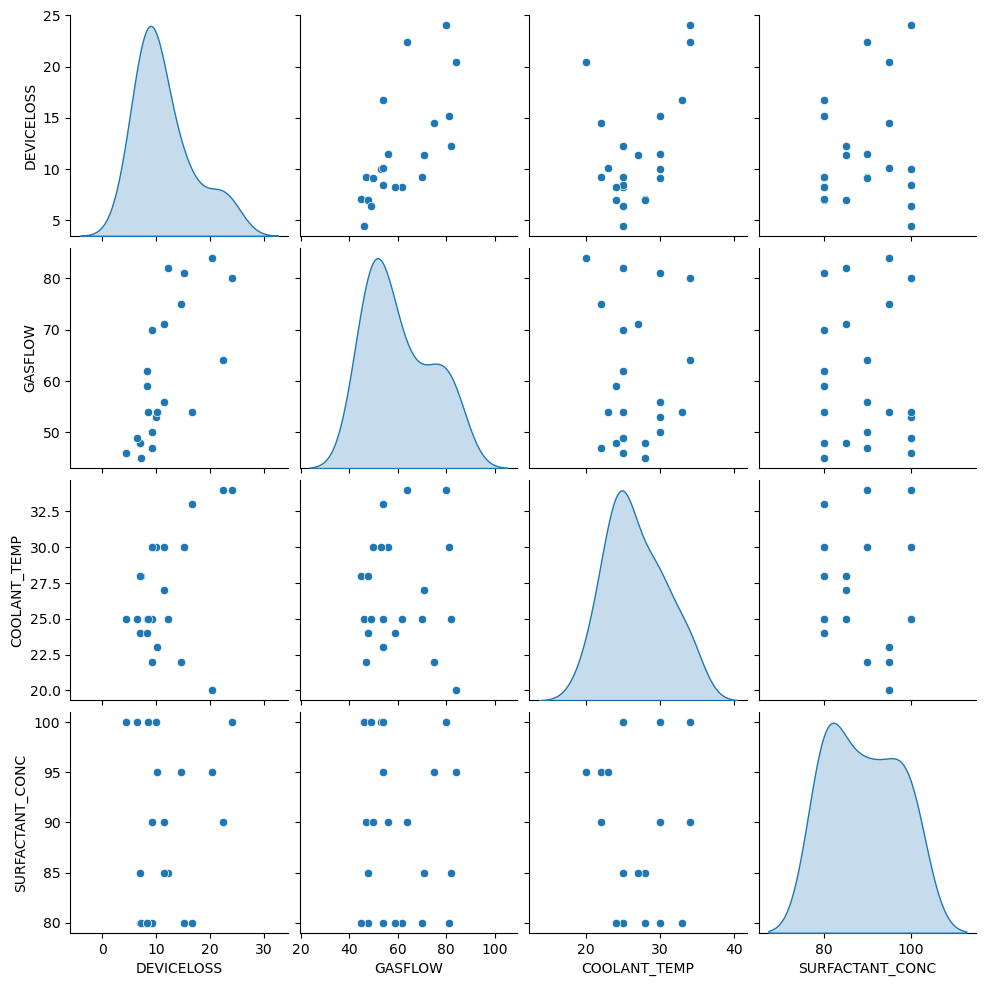

In [5]:
import seaborn as sns
pair_plot = sns.pairplot(train_df, diag_kind='kde')

The predictor that appears most strongly linearly associated with DEVICELOSS is GASFLOW predictor. The reason why is that for SURFACTANT_CONC, the pairplot shows that dots that are scattered around with no sort of linear association. The COOLANT_TEMP shows a almost "C" curvature that also does not show any sort of linear association. GASFLOW is the only predictor that shows slight linearity which suggest that GASFLOW is the predictor that appears most strongly associated with DEVICELOSS.

COOLANT_TEMP does suggest a curvature but it is non-linear. This curvature does not follow a simple linear patter, but instead has a "C" shape curvature which suggest that the relationship between COOLANT_TEMP and DEVICELOSS as being non-linear.

GASFLOW suggest a strong relationship due to its linearity, COOLANT_TEMP suggest a moderate relationship due to its "C" curvature, SUFACTANT_CONC suggest a weak relationship due to having no relationship between the plotted points to DEVICELOSS.

There is some level of heteroscedasticity for GASFLOW and COOLANT_TEMP as the values increase from 0, however there is high level of heteroscedasiticity from SURFACTANT_CONC as the values are seperated from eachother. Though, there does not seems any extreme levels of outliers between the predictors. 

**C) Calculate the mean vector, covariance matrix, and correlation matrix for the training data.**

**• DEVICELOSS, GASFLOW, COOLANT_TEMP, SURFACTANT_CONC**

**Write 2–4 sentences interpreting:**

**• What a positive/negative covariance means (direction of association)**

**• What the correlation magnitude suggests (weak/moderate/strong linear relationship)**

In [6]:
mean_vector = train_df.mean()

cov_matrix = train_df.cov()

corr_matrix = train_df.corr()

print(mean_vector)

print(cov_matrix)

print(corr_matrix)

DEVICELOSS         11.500909
GASFLOW            60.545455
COOLANT_TEMP       26.772727
SURFACTANT_CONC    89.090909
dtype: float64
                 DEVICELOSS     GASFLOW  COOLANT_TEMP  SURFACTANT_CONC
DEVICELOSS        28.209856   48.060909      8.963074         5.636580
GASFLOW           48.060909  173.021645     -0.632035        -4.718615
COOLANT_TEMP       8.963074   -0.632035     15.612554        -1.883117
SURFACTANT_CONC    5.636580   -4.718615     -1.883117        63.419913
                 DEVICELOSS   GASFLOW  COOLANT_TEMP  SURFACTANT_CONC
DEVICELOSS         1.000000  0.687925      0.427090         0.133261
GASFLOW            0.687925  1.000000     -0.012161        -0.045046
COOLANT_TEMP       0.427090 -0.012161      1.000000        -0.059845
SURFACTANT_CONC    0.133261 -0.045046     -0.059845         1.000000


A positive covariance indicates that when a predictor variable increases, the response variable will also increase with it as well. Conversely, a negative covariance indicates an inverse relationship where an predictor variable increases will result in the reponse variable to decrease. In the covariance matrix, all of the predictors (GASFLOW: 48,  COOLANT_TEMP: 8.9, and SURFACTANT_CONC: 5.63) have positive covariance.

The correlation magnitude suggest that a strong relationship must be close to +-1, and that a weak relationship is close to that of 0. In the correlation matrix, GASFLOW has a correlation of 0.68 (strong relationship), whereas COOLANT_TEMP is 0.43 (moderate relationship), and SURFACTANT_CONC is 0.13 (weak relationship). 

### Problem 2: [25 points/100 points] Simple Linear Regression

**a) Using the training data, fit Simple Linear Regression in Python for GASFLOW. Fit the model: DEVICELOSS=β0+β1(GASFLOW)+ε Show the fitted results summary2 output and interpret 𝛽0̂ , 𝛽1̂ , and R2, and MSE.**

In [7]:
import statsmodels.api as sm

X_train = train_df['GASFLOW']
y_train = train_df['DEVICELOSS']
X_train_const = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train_const).fit()

print(model.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.447   
Dependent Variable: DEVICELOSS       AIC:                124.7803
Date:               2026-03-20 05:46 BIC:                126.9624
No. Observations:   22               Log-Likelihood:     -60.390 
Df Model:           1                F-statistic:        17.97   
Df Residuals:       20               Prob (F-statistic): 0.000402
R-squared:          0.473            Scale:              15.603  
-------------------------------------------------------------------
           Coef.    Std.Err.      t      P>|t|     [0.025    0.975]
-------------------------------------------------------------------
const     -5.3170     4.0559   -1.3109   0.2047   -13.7776   3.1435
GASFLOW    0.2778     0.0655    4.2389   0.0004     0.1411   0.4145
-----------------------------------------------------------------
Omnibus:              7.318        Durbin-Watson:           1.826
Prob(Omnibus):   

The β0 coefficient, or also known as the intercept variable, has the value of -5.3170. This value means what will the y response (DEVICELOSS) percentage will be at when GASFLOW rate percentage is at 0%, which is -5.3170% of processed gas that is lost during operation when GASFLOW rate is at 0%. This means that that DEVICELOSS has to have some levels of GASFLOW in order for it to have a processed gas lost. 

The β1 coefficient, or also known as the slope of the model, has the value of 0.2778. This value indicates that for every 1% increase in GASFLOW rate,  the DEVICELOSS is expected to increase by approximately 0.2778%.

The R2 value, or R-squared, has the value of 0.473. This means that around 47.3% of the variation in DEVICELOSS can be explained by the linear relationship with GASFLOW. While GASFLOW is an important factor, more than half of the variability remains unexplained by this single linear predictor.

The MSE, or mean squared error, has the value of 15.603. The MSE measures the average squared difference between estimated values (predictions made by the predictor) and the actual true values. Therefore on average, the squared deviation of the predicted DEVICELOSS from the actual observed value is 15.603%^2 units.

**b) Show the ANOVA table for the fitted model from part a. Using this ANOVA table, show the
numerical calculations to verify the calculation of the F-statistic and R2. Interpret these
measures.**

In [20]:
from statsmodels.formula.api import ols

#simple ANOVA table 
model_formula = ols('DEVICELOSS ~ GASFLOW', data=train_df).fit()
anova_table = sm.stats.anova_lm(model_formula, typ=1)
print(anova_table)

#using ANOVA, numeric calculation to verify F-statistics and R^2
ssr = anova_table.loc['GASFLOW', 'sum_sq']   
sse = anova_table.loc['Residual', 'sum_sq']  
sst = ssr+sse                              
dfr = anova_table.loc['GASFLOW', 'df']      
dfe = anova_table.loc['Residual', 'df']    
msr = ssr/dfr
mse = sse/dfe
f_stat = msr/mse
r_squared = ssr/sst
print("")
print(f"F-statistic: {f_stat}")
print(f"R^2: {r_squared}")

            df      sum_sq     mean_sq         F    PR(>F)
GASFLOW    1.0  280.351459  280.351459  17.96805  0.000402
Residual  20.0  312.055523   15.602776       NaN       NaN

F-statistic: 17.968049828712747
R^2: 0.4732413149943953


In the ANOVA table, The large F-statistic relative to its critical value (and the very small p-value of 0.0004 which is less than 0.05) indicates that the model containing GASFLOW is significantly better at predicting DEVICELOSS. We reject the null hypothesis stating that there is a relationship between GASFLOW and DEVICELOSS)

From the ANOVA table, the R^2 value is 0.473. This has been previously states around 47.3% of the variation in DEVICELOSS can be explained by the linear relationship with GASFLOW.

**c) Using training data, Show the 95% CI and PI for the mean response at the mean of
GASFLOW. Interpret and discuss these intervals.**

In [22]:
mean_gasflow = X_train.mean()
X_point = sm.add_constant(pd.DataFrame({'GASFLOW': [mean_gasflow]}), has_constant='add')
print({mean_gasflow})
pred_results = model.get_prediction(X_point)
summary_frame = pred_results.summary_frame(alpha=0.05)
print(summary_frame[['mean', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']])

{np.float64(60.54545454545455)}
        mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  11.500909       9.744214      13.257604      3.076097     19.925721


The 95% CI interval for the mean response at the mean of GASFLOW is [9.74,13.26]. This interval provides a range where it is  95% confident the true population mean DEVICELOSS lies of the mean of GASFLOW is 60.54.

The 95% PI interval for the mean response at the mean of GASFLOW is [3.07,19.93]. This interval provides a range where it is 95% confident a single or individual future test result will fall when the GASFLOW is 60.54.

### Problem 3: [25 points/100 points] Forward Selection and Test the Model

**a) Using the training data, explore the best fit of DEVICELOSS as a function of
COOLANT_TEMP. Fit both a first-order (linear) model and a second-order (quadratic)
model for DEVICELOSS as a function of COOLANT_TEMP. Compare the models and
report the summary2 output for the better-fitting model.**

In [24]:
X1_const = sm.add_constant(train_df[['COOLANT_TEMP']])
model_linear = sm.OLS(train_df['DEVICELOSS'], X1_const).fit()
print(model_linear.summary2())

train_df['COOLANT_TEMP_SQ'] = train_df['COOLANT_TEMP']**2
X2_const = sm.add_constant(train_df[['COOLANT_TEMP', 'COOLANT_TEMP_SQ']])
model_quad = sm.OLS(train_df['DEVICELOSS'], X2_const).fit()

print(model_quad.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.142   
Dependent Variable: DEVICELOSS       AIC:                134.4521
Date:               2026-03-19 19:55 BIC:                136.6341
No. Observations:   22               Log-Likelihood:     -65.226 
Df Model:           1                F-statistic:        4.462   
Df Residuals:       20               Prob (F-statistic): 0.0474  
R-squared:          0.182            Scale:              24.217  
-----------------------------------------------------------------
                  Coef.  Std.Err.    t    P>|t|   [0.025   0.975]
-----------------------------------------------------------------
const            -3.8692   7.3515 -0.5263 0.6045 -19.2042 11.4659
COOLANT_TEMP      0.5741   0.2718  2.1123 0.0474   0.0072  1.1410
-----------------------------------------------------------------
Omnibus:              6.868        Durbin-Watson:           2.370
Prob(Omnibus):        0.032

When comparing the models, both linear and quadratic, it is seens that both have the P value are small, however in the quadratic one, it shows that the value to be very small compared to the linear model which is ~0.04. This shows that there is a drastic difference and dependability when the model is quadratic compared to when it is linear. Additionally, the R^2 went from 0.182 to 0.822, which means that this massive jump from 18% to 82% tells us that the quadratic term is capturing a major physical trend that the linear model completely missed.

**b) Using training data only, perform forward selection using R2 adjusted to identify the best
model using first or second order quadratic forms of GASFLOW, COOLANT_TEMP, and
SURFACTANT_CONC to predict mean DEVICELOSS. Clearly identify which model has the
highest adjusted R² with the order of entry and the adjusted R² at each step**

In [30]:
train_df['GASFLOW_SQ'] = train_df['GASFLOW']**2
train_df['COOLANT_TEMP_SQ'] = train_df['COOLANT_TEMP']**2
train_df['SURF_SQ'] = train_df['SURFACTANT_CONC']**2

candidates = ['GASFLOW', 'GASFLOW_SQ', 'COOLANT_TEMP', 'COOLANT_TEMP_SQ', 'SURFACTANT_CONC', 'SURF_SQ']
current_predictors = []
best_adj_r2 = -float('inf')

while True:
    best_candidate = None
    best_step_adj_r2 = -float('inf')
    
    for candidate in candidates:
        if candidate not in current_predictors:
            trial_X = sm.add_constant(train_df[current_predictors + [candidate]])
            model = sm.OLS(train_df['DEVICELOSS'], trial_X).fit()
            print(model.summary2())
            if model.rsquared_adj > best_step_adj_r2:
                best_step_adj_r2 = model.rsquared_adj
                best_candidate = candidate
    
    if best_step_adj_r2 > best_adj_r2:
        current_predictors.append(best_candidate)
        best_adj_r2 = best_step_adj_r2
    else:
        break

final_X = sm.add_constant(train_df[current_predictors])
print(sm.OLS(train_df['DEVICELOSS'], final_X).fit().summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.447   
Dependent Variable: DEVICELOSS       AIC:                124.7803
Date:               2026-03-19 21:16 BIC:                126.9624
No. Observations:   22               Log-Likelihood:     -60.390 
Df Model:           1                F-statistic:        17.97   
Df Residuals:       20               Prob (F-statistic): 0.000402
R-squared:          0.473            Scale:              15.603  
-------------------------------------------------------------------
           Coef.    Std.Err.      t      P>|t|     [0.025    0.975]
-------------------------------------------------------------------
const     -5.3170     4.0559   -1.3109   0.2047   -13.7776   3.1435
GASFLOW    0.2778     0.0655    4.2389   0.0004     0.1411   0.4145
-----------------------------------------------------------------
Omnibus:              7.318        Durbin-Watson:           1.826
Prob(Omnibus):   

The model that had the highest adjusted R^2 is forwarding COOLANT_TEMP when it jumped from 0.649 to 0.981and is the one that kept it at 0.981 which is the highest R^2 adjusted. The final model has GASFLOW, COOLANT_TEMP_SQ, and COOLANT_TEMP. The order of the first entry of COOLANT_TEMP was 13 and the adjusted R^2 for each steps is listed here:
1. 0.447 
2. 0.439
3. 0.142 
4. 0.196 
5. -0.031 
6. -0.033
7. 0.420
8. 0.627 
9. 0.664
10. 0.448
11. 0.446  
12. 0.649
13. 0.981
14. 0.685
15. 0.683
16. 0.980
17. 0.980
18. 0.980
19. 0.981

**c) Using the best model (as determined in part b):**

**• Compute Training MSE and RMSE.**

**• Compute Test MSE and RMSE.**

**• Compare training vs test performance.**

**• Discuss evidence of overfitting or underfitting**

In [21]:
import numpy as np

for data in [train_df, test_df]:
    data['GASFLOW_SQ'] = data['GASFLOW']**2
    data['COOLANT_TEMP_SQ'] = data['COOLANT_TEMP']**2
    data['SURFACTANT_CONC_SQ'] = data['SURFACTANT_CONC']**2

predictors = ['GASFLOW', 'GASFLOW_SQ', 'COOLANT_TEMP', 'COOLANT_TEMP_SQ', 'SURFACTANT_CONC', 'SURFACTANT_CONC_SQ']

X_train = sm.add_constant(train_df[predictors])
y_train = train_df['DEVICELOSS']
model = sm.OLS(y_train, X_train).fit()

y_train_pred = model.predict(X_train)
X_test = sm.add_constant(test_df[predictors])
y_test_pred = model.predict(X_test)
y_test = test_df['DEVICELOSS']

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print(f"Training MSE:  {mse_train}")
print(f"Training RMSE: {rmse_train}")
print(f"Test MSE:      {mse_test}")
print(f"Test RMSE:     {rmse_test}")

NameError: name 'mean_squared_error' is not defined

When comparing the Test RMSE and Training RMSE, the test RMSE is greater than the training RMSE. Therefore the training RMSE is better performance in the sense that it has a lower error than that of Test RMSE. 

Overfitting happens when (model too complex / learned noise):

RMSE: train ≪ test (e.g. train 0.5, test 2.1)

R²: train ≫ test (e.g. train 0.98, test 0.55)

Underfitting happens when (model too simple / wrong form):

RMSE: both big (e.g. train 18.5, test 18.7)

R²: both small (e.g. train 0.25, test 0.20)

In the example above, since both do not have high RMSE value, the model is not underfitting. However the model has slight overfitting as train < test but not by a significant amount.

### Problem 4: [25 points/100 points] Assumption Review and Final Model Interpretation

**a) Using the training data, show and interpret three of the following diagnostic plots:**

**• Residuals versus Fitted Plot**

**• QQ plot**

**• Influence Plot or Cook’s Distance**

**• Independence versus Order or ACF Plot (for run-order patterns)**

Text(0.5, 1.0, 'Residuals vs. Order Plot')

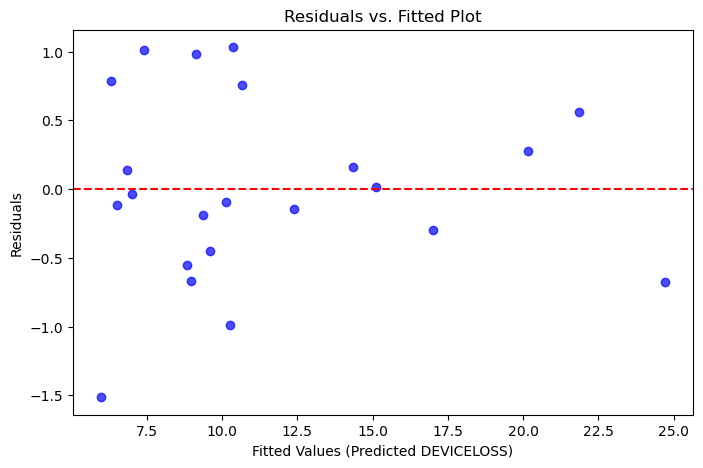

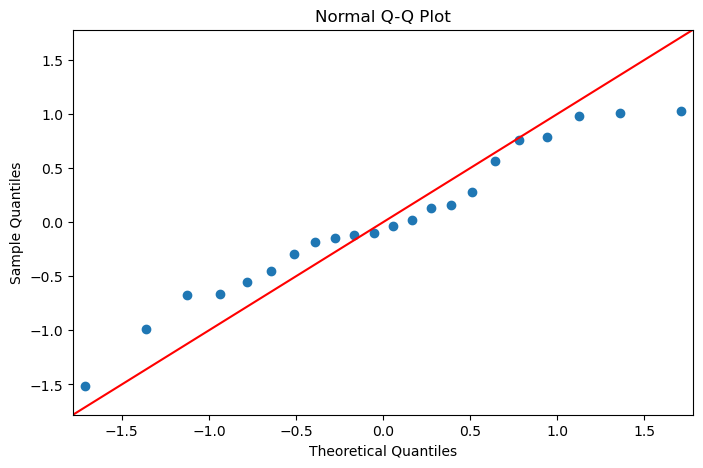

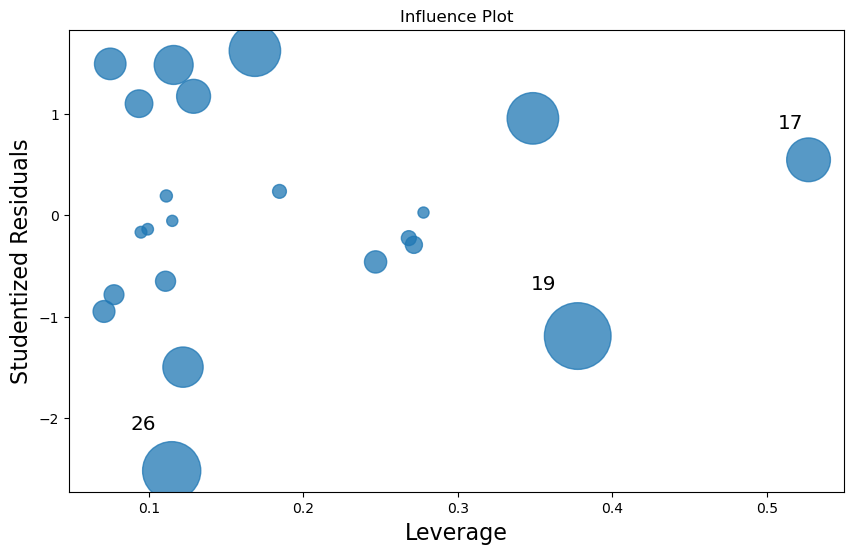

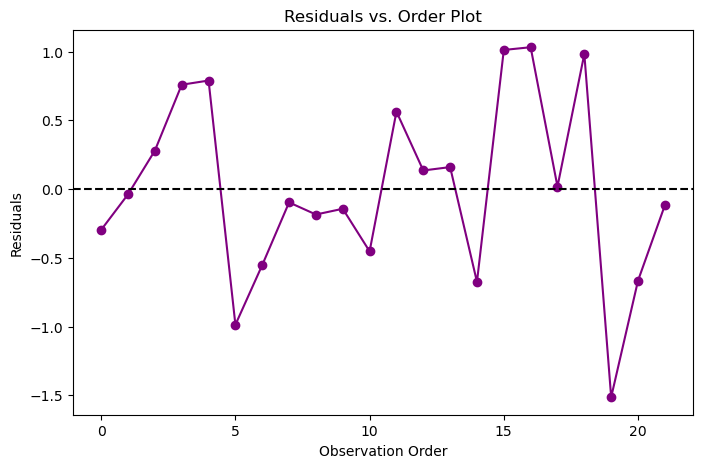

In [10]:
import matplotlib.pyplot as plt

train_df['COOLANT_TEMP_SQ'] = train_df['COOLANT_TEMP']**2
predictors = ['GASFLOW', 'COOLANT_TEMP', 'COOLANT_TEMP_SQ']
X_train = sm.add_constant(train_df[predictors])
y_train = train_df['DEVICELOSS']

#residuals versus fitted
model = sm.OLS(y_train, X_train).fit()
plt.figure(figsize=(8, 5))
plt.scatter(model.fittedvalues, model.resid, color='blue', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predicted DEVICELOSS)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Plot')

#Q-Q plot
fig, ax = plt.subplots(figsize=(8, 5))
sm.qqplot(model.resid, line='45', ax=ax)
plt.title('Normal Q-Q Plot')

#influence plot
fig, ax = plt.subplots(figsize=(10, 6))
sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
plt.title('Influence Plot')

#independence versus order 
plt.figure(figsize=(8, 5))
plt.plot(range(len(model.resid)), model.resid, marker='o', linestyle='-', color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Observation Order')
plt.ylabel('Residuals')
plt.title('Residuals vs. Order Plot')

The residual vs fitted plot shows that the error is at 0 and the variance is constant throughout. This shows the assumptions are correct and that the linear model is appropriate, the mean of the residuals is zero, and the constant variance (homoscedasticity) assumption is met.

The Q-Q plot shows that the graph is linear with a constant slope. This shows that assumptions of normality is correct that the residuals are normally distributed which the statistic test can be performed. 

The influence plot shows possible outliers in the model. In the model presented, the points hover within x value of -2 to y value of -2 with the exception of 26. This shows that there is not significant outliers that have heavily influence our model. 


**b) Using the entire dataset for final reporting precision, use the best model to fit and show the
Multiple Linear Regression summary2 results. Interpret each regression coefficient in
context.**

In [14]:
predictors = ['GASFLOW', 'COOLANT_TEMP', 'COOLANT_TEMP_SQ']

y = df['DEVICELOSS']
X = sm.add_constant(df[predictors])

final_model = sm.OLS(y, X).fit()

print(final_model.summary2())

                  Results: Ordinary least squares
Model:                OLS              Adj. R-squared:     0.975   
Dependent Variable:   DEVICELOSS       AIC:                75.6295 
Date:                 2026-03-20 06:31 BIC:                81.4925 
No. Observations:     32               Log-Likelihood:     -33.815 
Df Model:             3                F-statistic:        411.3   
Df Residuals:         28               Prob (F-statistic): 3.00e-23
R-squared:            0.978            Scale:              0.55382 
-------------------------------------------------------------------
                 Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
-------------------------------------------------------------------
const           134.3787   6.8895  19.5049 0.0000 120.2662 148.4911
GASFLOW           0.1764   0.0113  15.5887 0.0000   0.1532   0.1995
COOLANT_TEMP    -10.4943   0.5006 -20.9653 0.0000 -11.5196  -9.4689
COOLANT_TEMP_SQ   0.2014   0.0092  21.9794 0.0000   0.1826   0.220

for the entire dataset:
B0 is 134.38 which is the y-intercept that when GASFLOW, COOLANT_TEMP, and COOLANT_TEMP_SQ is at 0, then the DEVICELOSS percentage is 134.38.

B1 is 0.1764 which is the slope of the GASFLOW, that every percentage of GASFLOW increase DEVICELOSS by 0.1764.

B2 is -10.4943 which is the slope of the COOLANT_TEMP, that every increase of COOLANT_TEMP will decrease DEVICELOSS by -10.49.

B3 is 0.2014 which is the slope of the COOLANT_TEMP_SQ, that every increase of the COOLANT_TEMP_SQ will increase DEVICELOSS of 0.2014.

**c) Show the ANOVA table for the fitted model from part b. Using this ANOVA table, show the
numerical calculations to verify the calculation of the F-statistic and R2. Interpret these
measures.**

In [20]:
df['COOLANT_TEMP_SQ'] = df['COOLANT_TEMP']**2
formula = 'DEVICELOSS ~ GASFLOW + COOLANT_TEMP + COOLANT_TEMP_SQ'
model_formula = ols(formula, data=df).fit()

anova_table = sm.stats.anova_lm(model_formula, typ=1)

print(anova_table)

ss_reg = anova_table['sum_sq'].iloc[:-1].sum()  
ss_resid = anova_table['sum_sq'].iloc[-1]      
df_reg = anova_table['df'].iloc[:-1].sum()      
df_resid = anova_table['df'].iloc[-1]           
ms_reg = ss_reg / df_reg
ms_resid = ss_resid / df_resid
f_stat = ms_reg / ms_resid
r_squared = ss_reg / (ss_reg + ss_resid)

print(f"Calculated F-Statistic: {f_stat}")
print(f"Calculated R-Squared:   {r_squared}")

                   df      sum_sq     mean_sq           F        PR(>F)
GASFLOW           1.0  298.703271  298.703271  539.355064  7.779812e-20
COOLANT_TEMP      1.0  117.179934  117.179934  211.586538  1.403827e-14
COOLANT_TEMP_SQ   1.0  267.546228  267.546228  483.096193  3.365572e-19
Residual         28.0   15.506838    0.553816         NaN           NaN
Calculated F-Statistic: 411.34593139390034
Calculated R-Squared:   0.977813659678746


The average F-statistics amoung the GASFLOW, COOLANT_TEMP, and COOANT_TEMP_SQ is 411.34 as (539+211+483)/3 = 411. This F-value is large which results in a very low P-value, which shows that there is a relationship between these predictors and DEVICELOSS. The R^2 is very high which all 3 predictors account all the variance of DEVICELOSS.